In [1]:
#Import iport Libraries
#  1.Data Manipulation 
import numpy as np
import pandas as pd


# 2.Data Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

#Ignore Warnings

import warnings
warnings.filterwarnings("ignore")



In [27]:
#Load the Dataset

df = pd.read_csv(r"C:\Users\PC\Documents\DNS-Tunneling-Cyber-Threat-Detector\datasets\raw\dnsguard_ai_dataset.csv")

In [28]:
df.head()

,domain,query_type,label
0,analytics.assets.stackoverflow.com,TXT,benign
1,3450c6e1e2b523cffa4be9c82be80cc62d9b7a.dns.hom...,TXT,tunnel
2,status.instagram.edu,MX,benign
3,bd9309b41f4a806fc8926708ab44ba9845a2827c64bad....,AAAA,tunnel
4,zgzjyjpws5apkmurvdljez1ovzuzoibfh3m.bbc.co,TXT,tunnel


In [29]:
#check dataset Shape

print("Dataset Shape",df.shape)

Dataset Shape (10000, 3)


In [30]:
#check Column Names

print(df.columns.tolist())

['domain', 'query_type', 'label']


In [31]:
#check Data Types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   domain      10000 non-null  str  
 1   query_type  10000 non-null  str  
 2   label       10000 non-null  str  
dtypes: str(3)
memory usage: 234.5 KB


In [32]:
# check Missing value

df.isnull().sum()

domain        0
query_type    0
label         0
dtype: int64

In [33]:
#check Duplicate Rows

print("Dulicated rows : ", df.duplicated().sum())

Dulicated rows :  0


In [34]:
#check target Variable distribution

df['label'].value_counts()

label
benign    7000
tunnel    3000
Name: count, dtype: int64

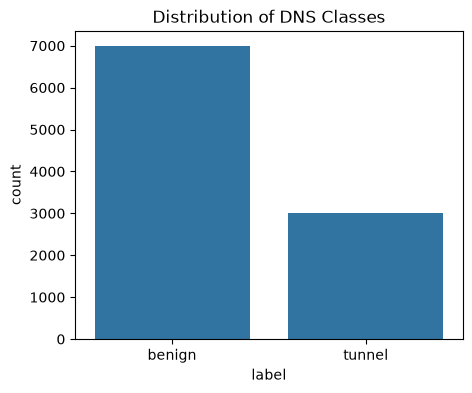

In [35]:
#Better Visulization

plt.figure(figsize = (5,4))

sns.countplot(data = df,x = "label")

plt.title("Distribution of DNS Classes")

plt.show()

Feature Engineering

In [36]:
def get_query_length(domain):
    """
    Return the total Number of Characters
    in the domain
    """

    return len(domain)


In [37]:
domain = "mail.goggle.com"

print(get_query_length(domain))

15


In [38]:
def get_num_labels(domain):

    """
    Return the total number of labels
    in the domain
    """

    return len(domain.split("."))


In [39]:
print(get_num_labels("mail.goggle.com"))

3


In [40]:
def get_avg_labels_lengths(domain):

    """
    Return the Average Length
    of all the lebels.

    """

    labels = domain.split(".")

    lengths = [len(label) for label in labels]

    return sum(lengths)/len(lengths)

In [41]:
print(get_avg_labels_lengths("mail.google.com"))

4.333333333333333


In [42]:
def get_subdomain_length(domain):
    """
    Return the total Length
    of the Subdomain
    """

    labels = domain.split(".")
    if len(labels)<=2:
        return 0
    subdomain =".".join(labels[:-2])

    return len(subdomain)

In [43]:
print(get_subdomain_length("abc123.mail.goggle.com"))

11


In [44]:
#Entropy

import math

def get_entropy(domain):
    """
    calculate the Shannon Entropy
    of a domain name.
    """

    #Count frequency of each Charcter


    char_counts= {}

    for char in domain:
        char_counts[char] = char_counts.get(char ,0)+1

    entropy = 0
    for count in char_counts.values():
        probability = count /len(domain) 
        entropy -= probability *math.log2(probability)

    return round(entropy ,3)      


In [45]:
# text
print(get_entropy("google.com"))

print(get_entropy("a8dk29xj29slq.google.com"))

2.646
3.97


In [46]:
print(get_entropy("google.com"))
print(get_entropy("mail.google.com"))
print(get_entropy("a8dk29xj29slq.google.com"))

2.646
3.057
3.97


In [47]:
def get_digit_ratio(domain):

    """
    Return the ratio of digits
    present in the domain.
    
    """
    digit_count = sum(c.isdigit() for c in domain)
    return round(digit_count / len(domain), 3)

In [48]:
print(get_digit_ratio("google.com"))

print(get_digit_ratio("abc123.google.com"))

print(get_digit_ratio("a8dk29xj29slq.google.com"))

0.0
0.176
0.208


In [49]:
#uncomman TLD(Top Level Domain) Feature

def get_uncomman_tld(domain):
    """
    Returns :
    0-> Comman TLD
    1-> Uncomman TLD
    """
    comman_tlds = [
        "com",
        "org",
        "net",
        "edu",
        "gov",
        "co",
        "io",
        "ai"
    ]

    tld  = domain.split(".")[-1].lower()

    if tld in comman_tlds:
        return 0 
    else:
        return 1

In [50]:
print(get_uncomman_tld("google.com"))
print(get_uncomman_tld("openai.ai"))
print(get_uncomman_tld("abc.xyz"))

0
0
1


This feature checks whether a domain uses a common or uncommon Top-Level Domain (TLD). While uncommon TLDs are not always malicious, they can provide an additional signal when combined with other features in the machine learning model.

In [53]:
#Create New feature from the domain columns

df["query_length"] = df["domain"].apply(get_query_length)
df["num_labels"] = df["domain"].apply(get_num_labels)
df["avg_label_length"] = df ["domain"].apply(get_avg_labels_lengths)
df["subdomain_length"] = df["domain"].apply(get_subdomain_length)
df["entropy"] =df["domain"].apply(get_entropy)
df ["digit_ratio"] = df["domain"].apply(get_digit_ratio)
df["uncomman_tld"] = df["domain"].apply(get_uncomman_tld)

In [54]:
df.head()

,domain,query_type,label,query_length,num_labels,avg_label_length,subdomain_length,entropy,digit_ratio,uncomman_tld
0,analytics.assets.stackoverflow.com,TXT,benign,34,4,7.750000,16,3.834,0.000,0
1,3450c6e1e2b523cffa4be9c82be80cc62d9b7a.dns.hom...,TXT,tunnel,55,4,13.000000,42,4.411,0.364,0
2,status.instagram.edu,MX,benign,20,3,6.000000,6,3.409,0.000,0
3,bd9309b41f4a806fc8926708ab44ba9845a2827c64bad....,AAAA,tunnel,60,3,19.333333,45,4.273,0.483,0
4,zgzjyjpws5apkmurvdljez1ovzuzoibfh3m.bbc.co,TXT,tunnel,42,3,13.333333,35,4.491,0.071,0


In [55]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   domain            10000 non-null  str    
 1   query_type        10000 non-null  str    
 2   label             10000 non-null  str    
 3   query_length      10000 non-null  int64  
 4   num_labels        10000 non-null  int64  
 5   avg_label_length  10000 non-null  float64
 6   subdomain_length  10000 non-null  int64  
 7   entropy           10000 non-null  float64
 8   digit_ratio       10000 non-null  float64
 9   uncomman_tld      10000 non-null  int64  
dtypes: float64(3), int64(4), str(3)
memory usage: 781.4 KB


In [56]:
df.describe()

,query_length,num_labels,avg_label_length,subdomain_length,entropy,digit_ratio,uncomman_tld
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0
mean,26.508700,3.37410,6.900109,15.747600,3.632881,0.071632,0.0
std,17.425226,1.10701,3.862428,17.071199,0.598285,0.129395,0.0
min,5.000000,2.00000,2.000000,0.000000,1.792000,0.000000,0.0
25%,14.000000,3.00000,4.333333,4.000000,3.236000,0.000000,0.0
50%,20.000000,3.00000,5.333333,8.000000,3.532500,0.000000,0.0
75%,35.000000,4.00000,8.750000,24.000000,4.112250,0.100000,0.0
max,112.000000,8.00000,22.000000,99.000000,5.059000,0.674000,0.0


In [58]:
#Compare feature means by class

df.groupby("label")[[

    "query_length",
    "subdomain_length",
    "num_labels",
    "avg_label_length",
    "entropy",
    "digit_ratio",
    "uncomman_tld"
]].mean()

,query_length,subdomain_length,num_labels,avg_label_length,entropy,digit_ratio,uncomman_tld
label,,,,,,,
benign,17.126000,6.453143,3.132857,4.724855,3.311308,0.005804,0.0
tunnel,48.401667,37.434667,3.937000,11.975703,4.383216,0.225231,0.0


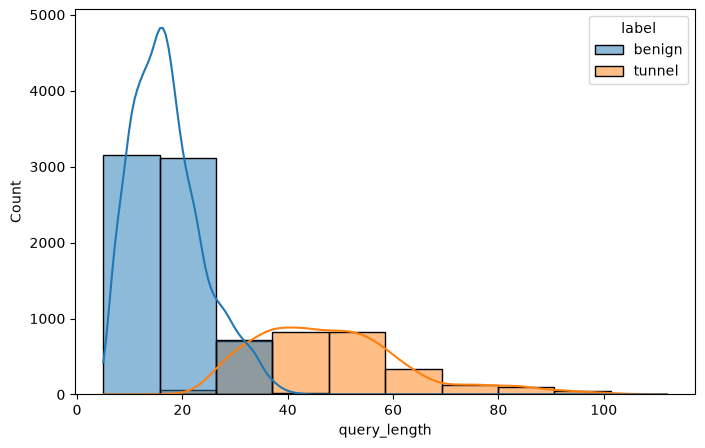

In [60]:
#Distribution of Query Length

plt.figure(figsize=(8,5))

sns.histplot(
    data = df,
    x= "query_length",
    hue = "label",
    bins = 10,
    kde = True
)

plt.title = "Query Length of Distribution"

plt.show()

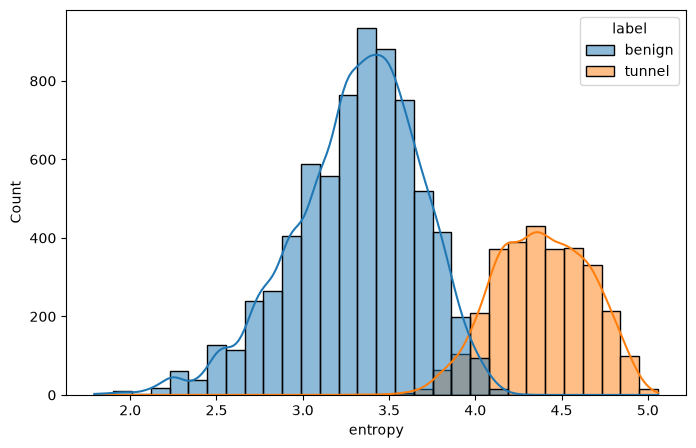

In [62]:
#Entropy Distribution

plt.figure(figsize=(8,5))

sns.histplot(

    data= df,
    x="entropy",
    hue ="label",
    bins = 30,
    kde = True



)

plt.title = "Entropy Distribution"
plt.show()


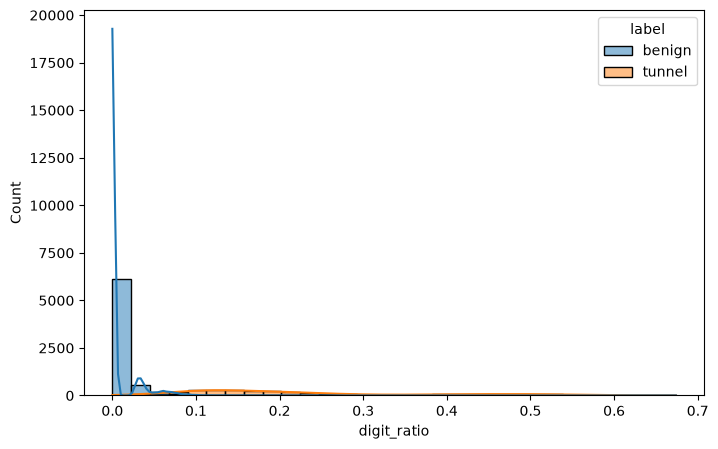

In [65]:
#Digit Ration Distribution

plt.figure(figsize=(8,5))

sns.histplot(

    data= df,
    x ="digit_ratio",
    hue = "label",
    bins =30,
    kde = True
)
plt.title ="Digit Ratio Distribution"
plt.show()

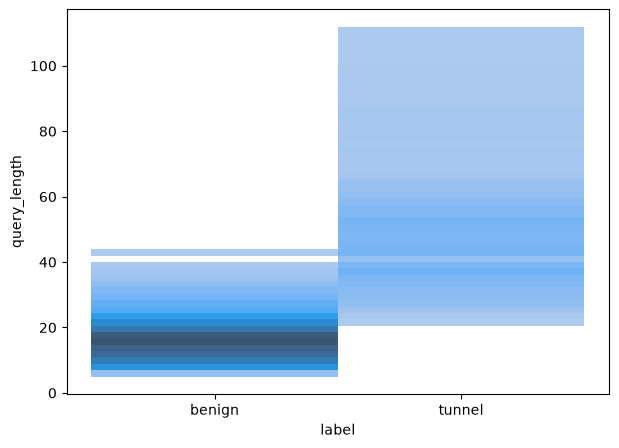

In [66]:
#Box plot comparison

plt.figure(figsize= (7,5))

sns.histplot(
    data=df,
    x ="label",
    y ="query_length",
    
)
plt.title = "Query Length of Class"

plt.show()

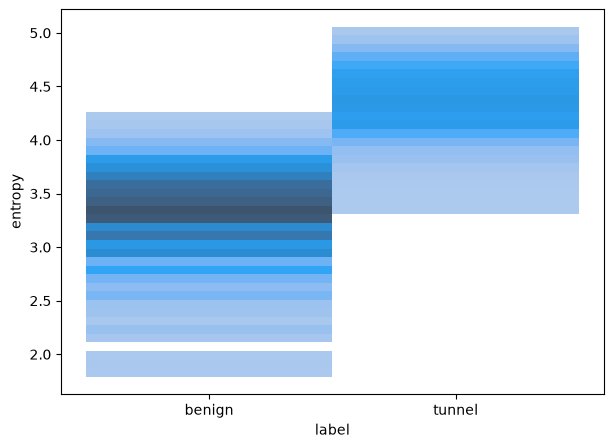

In [67]:
#Entropy Class

plt.figure(figsize=(7,5))
sns.histplot(

    data= df,
    x = "label",
    y = "entropy"
)

plt.title = "Entropy of Class"
plt.show()

In [77]:
numerical_columns = [
    "query_length",
    "subdomain_length",
    "num_labels",
    "avg_label_length",
    "entropy",
    "digit_ratio",
    "uncomman_tld"
]

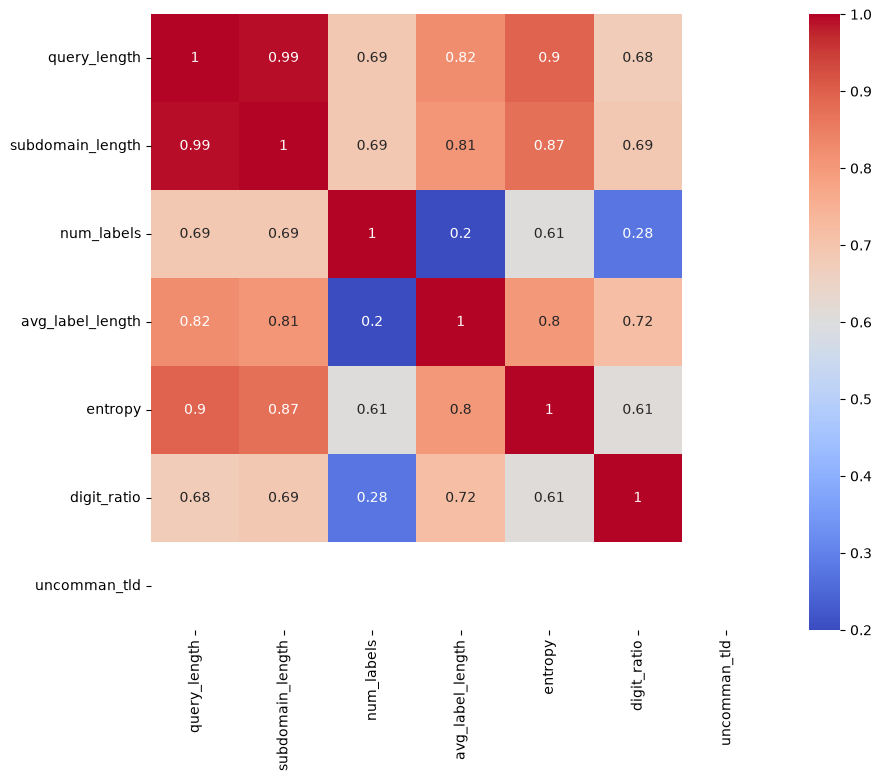

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title = "Correlation Matrix"

plt.show()

DATA PREPROCESSING

In [80]:
df.drop(columns = "domain", inplace = True)

In [81]:
df.head()

,query_type,label,query_length,num_labels,avg_label_length,subdomain_length,entropy,digit_ratio,uncomman_tld
0,TXT,benign,34,4,7.750000,16,3.834,0.000,0
1,TXT,tunnel,55,4,13.000000,42,4.411,0.364,0
2,MX,benign,20,3,6.000000,6,3.409,0.000,0
3,AAAA,tunnel,60,3,19.333333,45,4.273,0.483,0
4,TXT,tunnel,42,3,13.333333,35,4.491,0.071,0


After feature engineering, I removed the original domain column because all relevant information had already been converted into numerical features.

In [82]:
#Separate Feature and Target Column

X = df.drop("label",axis =1)
y =df["label"]

In [83]:
print(X.head())

  query_type  query_length  num_labels  avg_label_length  subdomain_length  \
0        TXT            34           4          7.750000                16   
1        TXT            55           4         13.000000                42   
2         MX            20           3          6.000000                 6   
3       AAAA            60           3         19.333333                45   
4        TXT            42           3         13.333333                35   

   entropy  digit_ratio  uncomman_tld  
0    3.834        0.000             0  
1    4.411        0.364             0  
2    3.409        0.000             0  
3    4.273        0.483             0  
4    4.491        0.071             0  


In [84]:
print(y.head())

0    benign
1    tunnel
2    benign
3    tunnel
4    tunnel
Name: label, dtype: str


In [106]:
#Identify Numerical and Categorical Columns
categorical_columns = ["query_type"]

numerical_columns = [
    "query_length",
    "subdomain_length",
    "num_labels",
    "avg_label_length",
    "entropy",
    "digit_ratio",
    "uncomman_tld"
]

In [107]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [108]:
#Create Numerical Pipeline
numeric_pipeline = Pipeline(
    steps = [
        ("scaler",StandardScaler())
    ]
)

In [109]:
#Create Categorical Pipeline

categorical_pipline = Pipeline(
    steps = [
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore",sparse_output=False)
        )
    ]
)



In [110]:
#Create Column Transformer

preprocessor = ColumnTransformer(
    transformers = [
        ("num",numeric_pipeline,numerical_columns),
        ("cat",categorical_pipline,categorical_columns)
    ]
)


In [111]:
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['query_length', 'subdomain_length',
                                  'num_labels', 'avg_label_length', 'entropy',
                                  'digit_ratio', 'uncomman_tld']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['query_type'])])


TrainTESTSplit

In [112]:
from sklearn.model_selection import train_test_split

In [113]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

I used stratify=y to preserve the original class distribution in both the training and testing sets, ensuring fair model evaluation.

In [114]:
print("X_train :", X_train.shape)
print("X_test:",X_test.shape)
print("y_train :",y_train.shape)
print("y_test :",y_test.shape)

X_train : (8000, 8)
X_test: (2000, 8)
y_train : (8000,)
y_test : (2000,)


In [115]:
#Verify Class Distribution

print(y_train.value_counts(normalize = True))

label
benign    0.7
tunnel    0.3
Name: proportion, dtype: float64


In [116]:
print(y_test.value_counts(normalize=True))

label
benign    0.7
tunnel    0.3
Name: proportion, dtype: float64


MODEL TRAINING

In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

In [118]:
#Create Logistic Regression Pipeline

logistic_pipeline = Pipeline(
    steps =[
        ("preprocessor",preprocessor),
        ("model",LogisticRegression(random_state=42))
    ]
)

In [120]:
logistic_pipeline.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['benign','tunnel']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['query_type','query_length','num_labels',...,'entropy','digit_ratio', 'uncomman_tld']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [121]:
y_pred_lr = logistic_pipeline.predict(X_test)

In [122]:
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr
})

prediction_df.head(10)

,Actual,Predicted
0,benign,benign
1,benign,benign
2,benign,benign
3,benign,benign
4,benign,benign
5,tunnel,tunnel
6,tunnel,tunnel
7,benign,benign
8,benign,benign
9,tunnel,tunnel


MODEL EVALUATION

In [125]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [126]:
accuracy = accuracy_score(y_test,y_pred_lr)
print("Accuracy :", accuracy)

Accuracy : 0.999


In [127]:
#classification Report

print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

      benign       1.00      1.00      1.00      1400
      tunnel       1.00      1.00      1.00       600

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [128]:
#Confusion Matrix

cm = confusion_matrix(y_test,y_pred_lr)

print(cm)

[[1400    0]
 [   2  598]]


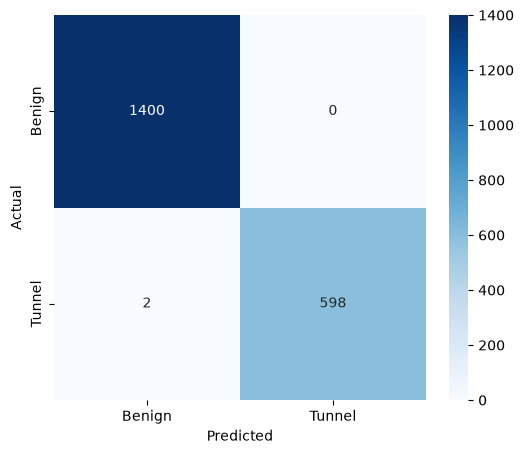

In [130]:
#plot Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Tunnel"],
    yticklabels=["Benign", "Tunnel"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title ="Confusion Matrix - Logistic Regression"

plt.show()

In [131]:
#Store the result
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr)],
    "Precision": [precision_score(y_test, y_pred_lr, pos_label="tunnel")],
    "Recall": [recall_score(y_test, y_pred_lr, pos_label="tunnel")],
    "F1-Score": [f1_score(y_test, y_pred_lr, pos_label="tunnel")]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.999,1.0,0.996667,0.998331


In [133]:
#Decision  Tree
decision_tree_pipeline = Pipeline(
    steps =[
        ("preprocessor",preprocessor),
        ("model",DecisionTreeClassifier(random_state=42))

    ]
)

In [134]:
decision_tree_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['benign','tunnel']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['query_type','query_length','num_labels',...,'entropy','digit_ratio', 'uncomman_tld']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [135]:
y_pred_dt  =decision_tree_pipeline.predict(X_test)

In [136]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

      benign       1.00      1.00      1.00      1400
      tunnel       1.00      0.99      1.00       600

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



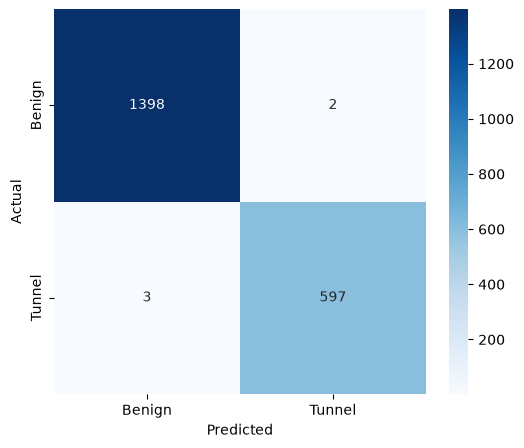

In [138]:
#Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Tunnel"],
    yticklabels=["Benign", "Tunnel"]
)

plt.title = "Decision Tree Confusion Matrix"

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [139]:
#Save Results
results.loc[len(results)] = [
    "Decision Tree",
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt, pos_label="tunnel"),
    recall_score(y_test, y_pred_dt, pos_label="tunnel"),
    f1_score(y_test, y_pred_dt, pos_label="tunnel")
]

In [140]:
#create Pipeline
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

In [142]:
random_forest_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['benign','tunnel']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['query_type','query_length','num_labels',...,'entropy','digit_ratio', 'uncomman_tld']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

In [143]:
y_pred_rf = random_forest_pipeline.predict(X_test)

In [145]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

      benign       1.00      1.00      1.00      1400
      tunnel       1.00      0.99      1.00       600

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



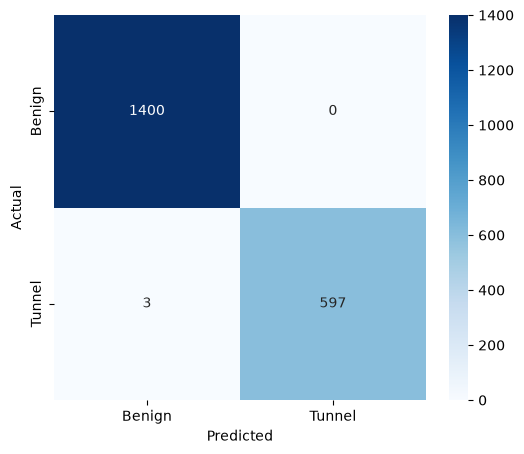

In [148]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Tunnel"],
    yticklabels=["Benign", "Tunnel"]
)

plt.title ="Random Forest Confusion Matrix"

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [149]:
#Save result
results.loc[len(results)] = [
    "Random Forest",
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf, pos_label="tunnel"),
    recall_score(y_test, y_pred_rf, pos_label="tunnel"),
    f1_score(y_test, y_pred_rf, pos_label="tunnel")
]

In [150]:
#comapre all result
results.sort_values(by ="Accuracy",ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9990,1.000000,0.996667,0.998331
2,Random Forest,0.9985,1.000000,0.995000,0.997494
1,Decision Tree,0.9975,0.996661,0.995000,0.995830


Different machine learning algorithms learn patterns differently. I trained Logistic Regression as a baseline model, Decision Tree for rule-based learning, and Random Forest as an ensemble method. I compared their performance using Accuracy, Precision, Recall, and F1-Score, then selected the best-performing model for deployment.

SAVE THE BEST MODEL (THAT IS LOGOSTC REGRESSION BECAUSE ACCURACY IS HIGH)

In [151]:
import joblib

In [157]:
joblib.dump(logistic_pipeline,"dnsguard_models.pkl")

['dnsguard_models.pkl']

In [153]:
#Save Model Class
print(logistic_pipeline.classes_)

['benign' 'tunnel']


In [154]:
#load the model
loaded_model = joblib.load("dnsguard_model.pkl")

In [156]:
#verify its work
loaded_model.predict(X_test.head())


array(['benign', 'benign', 'benign', 'benign', 'benign'], dtype=object)